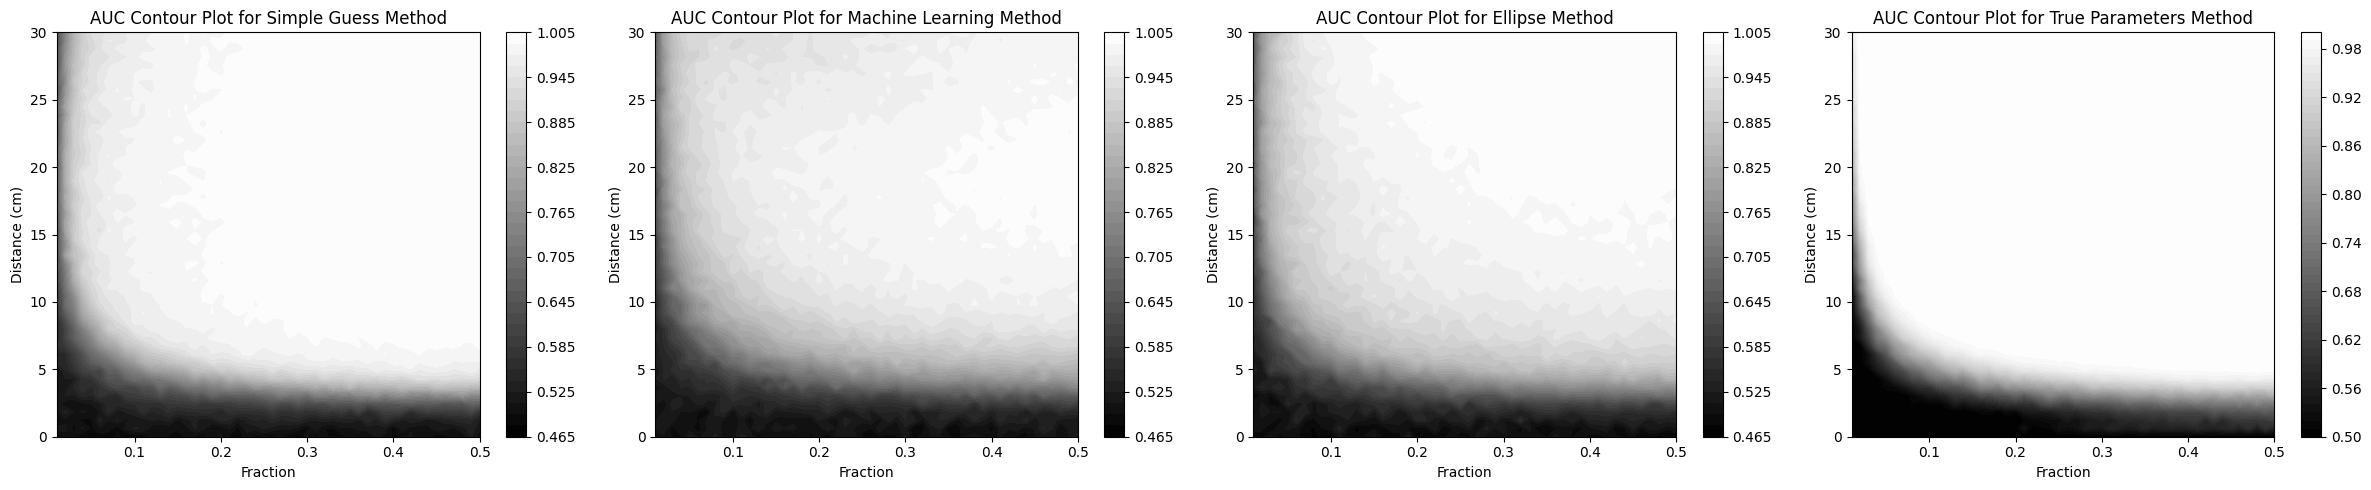

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

distances_3 = np.linspace(0, 30, 50)
Fractions_3 = np.linspace(0.01, 0.5, 50)

Fractions_2 = np.linspace(0.01, 0.5, 100)
distances_2 = np.linspace(0, 30, 150)

auc_chi_squared_method = pd.read_csv(r"C:\Users\Gebruiker\XENONnT_pmt_statistics\csvs\auc_results.csv")
auc_simple_guess_method = pd.read_csv(r"C:\Users\Gebruiker\XENONnT_pmt_statistics\csvs\auc_results_simple_guess.csv")
auc_results_machine_learning_method = pd.read_csv(r"C:\Users\Gebruiker\XENONnT_pmt_statistics\csvs\auc_results_machine_learning_50_50.csv")
auc_results_ellipse_method = pd.read_csv(r"C:\Users\Gebruiker\XENONnT_pmt_statistics\csvs\auc_results_ellipse_guess.csv")
df = pd.read_csv(r"C:\Users\Gebruiker\XENONnT_pmt_statistics\csvs\auc_results_true_parameters.csv")
#setting all value in below 0.5, to 0.5 to account for overfitting issues
df[df < 0.5] = 0.5
auc_results_true_parameters = df

#Make contour plot for all 4 separately
plt.figure(figsize=(24, 5))
#Chi-squared method
plt.subplot(1, 4, 1)
X, Y = np.meshgrid(Fractions_3, distances_3)
Z = auc_simple_guess_method.values  # Assuming the AUC values are in the csv
contour = plt.contourf(X, Y, Z, levels=50, cmap='grey')
plt.colorbar(contour)
plt.xlabel('Fraction')
plt.ylabel('Distance (cm)')
plt.title('AUC Contour Plot for Simple Guess Method')
#Simple guess method
plt.subplot(1, 4, 2)
X, Y = np.meshgrid(Fractions_3, distances_3)
Z = auc_results_machine_learning_method.values  # Assuming the AUC values are in the csv
contour = plt.contourf(X, Y, Z, levels=50, cmap='grey')
plt.colorbar(contour)
plt.xlabel('Fraction')
plt.ylabel('Distance (cm)')
plt.title('AUC Contour Plot for Machine Learning Method')
#Machine learning method
plt.subplot(1, 4, 3)
X, Y = np.meshgrid(Fractions_3, distances_3)
Z = auc_results_ellipse_method.values  # Assuming the AUC values are in the csv
contour = plt.contourf(X, Y, Z, levels=50, cmap='grey')
plt.colorbar(contour)
plt.xlabel('Fraction')
plt.ylabel('Distance (cm)')
plt.title('AUC Contour Plot for Ellipse Method')
#True parameters method
plt.subplot(1, 4, 4)
X, Y = np.meshgrid(Fractions_3, distances_3)
Z = auc_results_true_parameters.values  # Assuming the AUC values are in the csv
contour = plt.contourf(X, Y, Z, levels=50, cmap='grey')
plt.colorbar(contour)
plt.xlabel('Fraction')
plt.ylabel('Distance (cm)')
plt.title('AUC Contour Plot for True Parameters Method')
plt.tight_layout()
plt.show()


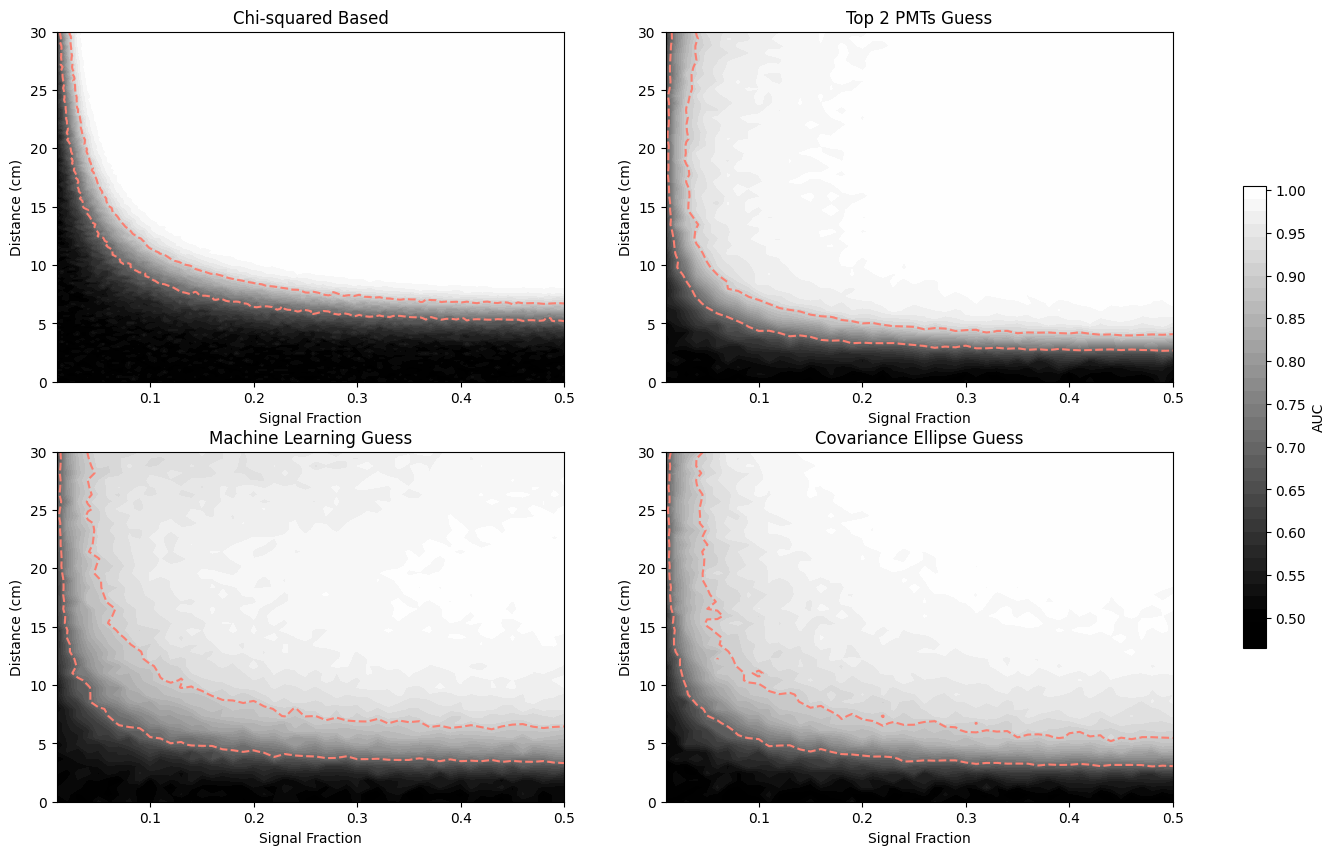

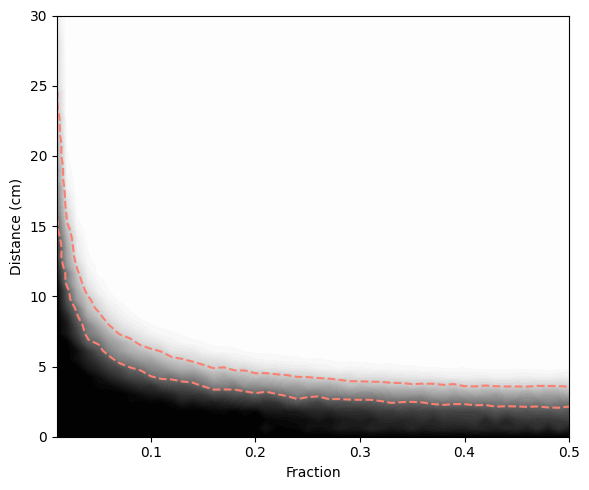

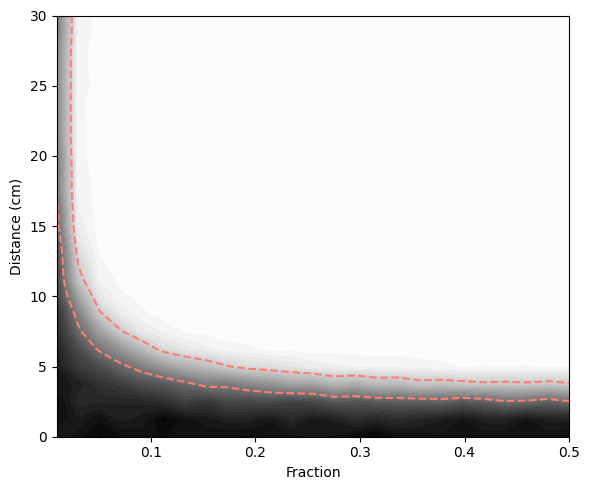

C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_14592\339997210.py:95: UserWarning: The following kwargs were not used by contour: 'labels'
  contour = plt.contour(X, Y, Z_smooth, levels=[0.7, 0.9], colors='black', linestyles=['dashed', 'solid'], labels=['Chi-squared 0.7', 'Chi-squared 0.9'])
C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_14592\339997210.py:103: UserWarning: The following kwargs were not used by contour: 'labels'
  contour = plt.contour(X, Y, Z_smooth, levels=[0.7, 0.9], colors='orange', linestyles=['dashed', 'solid'], labels=['Simple Guess 0.7', 'Simple Guess 0.9'])
C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_14592\339997210.py:108: UserWarning: The following kwargs were not used by contour: 'labels'
  contour = plt.contour(X, Y, Z_smooth, levels=[0.7, 0.9], colors='green', linestyles=['dashed', 'solid'], labels=['Machine Learning 0.7', 'Machine Learning 0.9'])
C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_14592\339997210.py:113: UserWarning: The following kwar

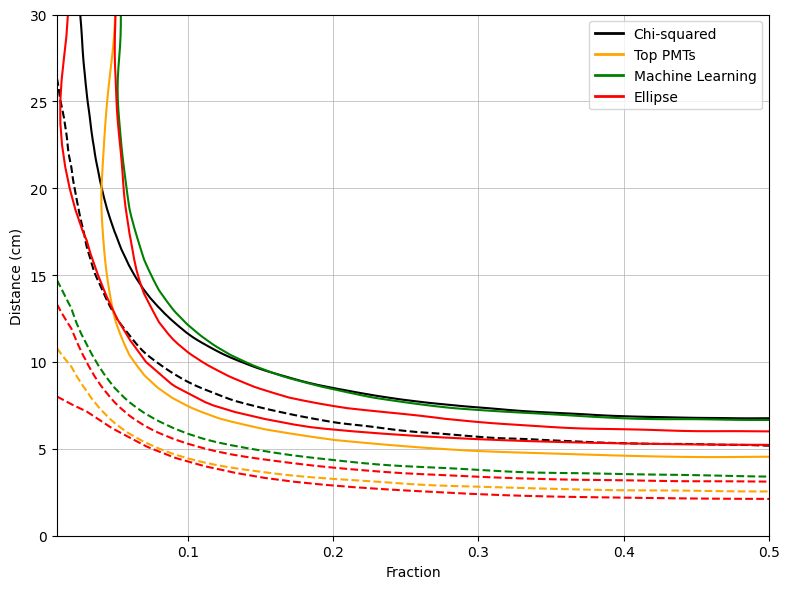

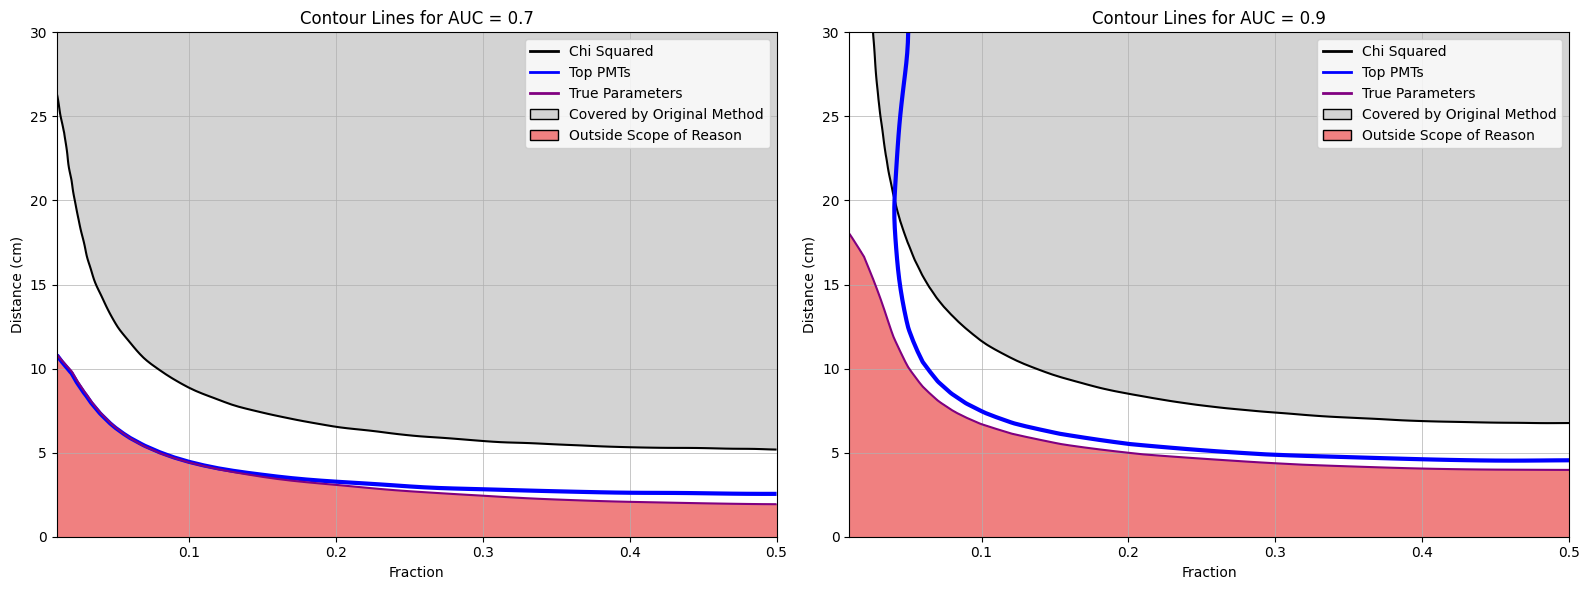

In [5]:
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

cmap = LinearSegmentedColormap.from_list('orange_green', ['darkorange', 'darkgreen'])

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Chi-squared method
ax = axes[0, 0]
X, Y = np.meshgrid(Fractions_2, distances_2)
Z = auc_chi_squared_method.values
contour = ax.contourf(X, Y, Z, levels=50, cmap='gray', vmin=0.5, vmax=1.0)
ax.contour(X, Y, Z, levels=[0.7, 0.9], colors='salmon', linestyles='dashed')
ax.set_xlabel('Signal Fraction')
ax.set_ylabel('Distance (cm)')
ax.set_title('Chi-squared Based')

# Simple guess method
ax = axes[0, 1]
X, Y = np.meshgrid(Fractions_3, distances_3)
Z = auc_simple_guess_method.values
contour = ax.contourf(X, Y, Z, levels=50, cmap='gray', vmin=0.5, vmax=1.0)
ax.contour(X, Y, Z, levels=[0.7, 0.9], colors='salmon', linestyles='dashed')
ax.set_xlabel('Signal Fraction')
ax.set_ylabel('Distance (cm)')
ax.set_title('Top 2 PMTs Guess')

# Machine learning method
ax = axes[1, 0]
X, Y = np.meshgrid(Fractions_3, distances_3)
Z = auc_results_machine_learning_method.values
contour = ax.contourf(X, Y, Z, levels=50, cmap='gray', vmin=0.5, vmax=1.0)
ax.contour(X, Y, Z, levels=[0.7, 0.9], colors='salmon', linestyles='dashed')
ax.set_xlabel('Signal Fraction')
ax.set_ylabel('Distance (cm)')
ax.set_title('Machine Learning Guess')

# Ellipse method
ax = axes[1, 1]
X, Y = np.meshgrid(Fractions_3, distances_3)
Z = auc_results_ellipse_method.values
contour = ax.contourf(X, Y, Z, levels=50, cmap='gray', vmin=0.5, vmax=1.0)
ax.contour(X, Y, Z, levels=[0.7, 0.9], colors='salmon', linestyles='dashed')
ax.set_xlabel('Signal Fraction')
ax.set_ylabel('Distance (cm)')
ax.set_title('Covariance Ellipse Guess')

# Single shared colorbar on the right
fig.colorbar(contour, ax=axes, location='right', shrink=0.6, label='AUC', ticks=np.linspace(0.5, 1.0, 11))
plt.show()

df = pd.read_csv(r"C:\Users\Gebruiker\XENONnT_pmt_statistics\csvs\auc_results_true_parameters.csv")
#setting all value in below 0.5, to 0.5 to account for overfitting issues
df[df < 0.5] = 0.5
auc_results_true_parameters = df

#same plot for true parameters
plt.figure(figsize=(6, 5))
X, Y = np.meshgrid(Fractions_3, distances_3)
Z = auc_results_true_parameters.values  # Assuming the AUC values are in the csv
plt.contourf(X, Y, Z, levels=50, cmap='gray')
plt.colorbar(contour)
#contours
plt.contour(X, Y, Z, levels=[0.7, 0.9], colors='salmon', linestyles='dashed')
plt.xlabel('Fraction')
plt.ylabel('Distance (cm)')
plt.tight_layout()
plt.show()

three_methods = pd.read_csv(r"C:\Users\Gebruiker\XENONnT_pmt_statistics\csvs\auc_results_3_guesses.csv")
distances_4 = np.linspace(0, 30, 25)
Fractions_4 = np.linspace(0.01, 0.5, 25)
plt.figure(figsize=(6, 5))
X, Y = np.meshgrid(Fractions_4, distances_4)
Z = three_methods  # Assuming the AUC values are in the csv
plt.contourf(X, Y, Z, levels=50, cmap='gray')
plt.colorbar(contour)
#contours
plt.contour(X, Y, Z, levels=[0.7, 0.9], colors='salmon', linestyles='dashed')
plt.xlabel('Fraction')
plt.ylabel('Distance (cm)')
plt.tight_layout()
plt.show()

#New plot showing contour lines for 0.7 and 0.9 for all 5, colour coded by method, 0.7 dashed, 0.9 solid, with gaussian smoothing for contour lines
plt.figure(figsize=(8, 6))
#make grid lines
plt.grid(True, which='both', axis='both', linewidth=0.5)
# Chi-squared method
X, Y = np.meshgrid(Fractions_2, distances_2)
Z = auc_chi_squared_method.values
Z_smooth = gaussian_filter(Z, sigma=2)
contour = plt.contour(X, Y, Z_smooth, levels=[0.7, 0.9], colors='black', linestyles=['dashed', 'solid'], labels=['Chi-squared 0.7', 'Chi-squared 0.9'])
#make grey everything above 0.9 contour line
#plt.contourf(X, Y, Z_smooth, levels=[0.9, np.inf], colors=['lightgrey'], alpha=1)

# Simple guess method
X, Y = np.meshgrid(Fractions_3, distances_3)
Z = auc_simple_guess_method.values
Z_smooth = gaussian_filter(Z, sigma=2)
contour = plt.contour(X, Y, Z_smooth, levels=[0.7, 0.9], colors='orange', linestyles=['dashed', 'solid'], labels=['Simple Guess 0.7', 'Simple Guess 0.9'])
# Machine learning method
X, Y = np.meshgrid(Fractions_3, distances_3)
Z = auc_results_machine_learning_method.values
Z_smooth = gaussian_filter(Z, sigma=2)
contour = plt.contour(X, Y, Z_smooth, levels=[0.7, 0.9], colors='green', linestyles=['dashed', 'solid'], labels=['Machine Learning 0.7', 'Machine Learning 0.9'])
# Ellipse method
X, Y = np.meshgrid(Fractions_3, distances_3)
Z = auc_results_ellipse_method.values
Z_smooth = gaussian_filter(Z, sigma=2)
contour = plt.contour(X, Y, Z_smooth, levels=[0.7, 0.9], colors='red', linestyles=['dashed', 'solid'], labels=['Best of 3 0.7', 'Best of 3 0.9'])
# Best of 3 methods
X, Y = np.meshgrid(Fractions_4, distances_4)
Z = three_methods
Z_smooth = gaussian_filter(Z, sigma=2)
contour = plt.contour(X, Y, Z_smooth, levels=[0.7, 0.9], colors='red', linestyles=['dashed', 'solid'], labels=['Ellipse 0.7', 'Ellipse 0.9'])
# Create a custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', lw=2, linestyle='solid', label='Chi-squared'),
    Line2D([0], [0], color='orange', lw=2, linestyle='solid', label='Top PMTs'),
    Line2D([0], [0], color='green', lw=2, linestyle='solid', label='Machine Learning'),
    Line2D([0], [0], color='red', lw=2, linestyle='solid', label='Ellipse'),
]
plt.legend(handles=legend_elements, loc='upper right')
plt.xlabel('Fraction')
plt.ylabel('Distance (cm)')
plt.tight_layout()
plt.show()

#make this again, but 2 subplots, for only 0.7 and only 0.9
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

levels = [0.7, 0.9]
titles = ['AUC = 0.7', 'AUC = 0.9']

methods = [
    (auc_chi_squared_method.values,  np.meshgrid(Fractions_2, distances_2), 'black',  'Chi Squared'),
    (auc_simple_guess_method.values, np.meshgrid(Fractions_3, distances_3), 'blue', 'Top PMTs'),
    (auc_results_true_parameters.values, np.meshgrid(Fractions_3, distances_3), 'purple', 'True Parameters')
    #, (three_methods, np.meshgrid(Fractions_4, distances_4), 'blue', 'Best of 3')
]

legend_elements = [
    Line2D([0], [0], color='black',     lw=2, label='Chi Squared'),
    Line2D([0], [0], color='blue',    lw=2, label='Top PMTs'),
    Line2D([0], [0], color='purple',    lw=2, label='True Parameters'),
    Patch(facecolor='lightgrey', edgecolor='black', label='Covered by Original Method'),
    Patch(facecolor='lightcoral', edgecolor='black', label='Outside Scope of Reason')
]

for i, (ax, level, title) in enumerate(zip(axes, levels, titles)):
    for Z_raw, (X, Y), color, label in methods:
        Z_smooth = gaussian_filter(Z_raw, sigma=2)
        #increase linewidth for top PMTs guess
        lw = 3.0 if label == 'Top PMTs' else 1.5
        ax.contour(X, Y, Z_smooth, levels=[level], colors=color, linestyles='solid', linewidths=lw)

    # Grey fill above 0.9 for chi-squared only
    Z_chi_smooth = gaussian_filter(auc_chi_squared_method.values, sigma=2)
    X2, Y2 = np.meshgrid(Fractions_2, distances_2)
    ax.contourf(X2, Y2, Z_chi_smooth, levels=[level, np.inf], colors=['lightgrey'], alpha=1)
    
    Z_true_smooth = gaussian_filter(auc_results_true_parameters.values, sigma=2)
    X3, Y3 = np.meshgrid(Fractions_3, distances_3)
    ax.contourf(X3, Y3, Z_true_smooth, levels=[-np.inf, level], colors=['lightcoral'])



    ax.set_xlabel('Fraction')
    ax.set_ylabel('Distance (cm)')
    ax.set_title(f'Contour Lines for {title}')
    ax.legend(handles=legend_elements, loc='upper right')
    ax.grid(True, which='both', linewidth=0.5)



plt.tight_layout()
plt.show()

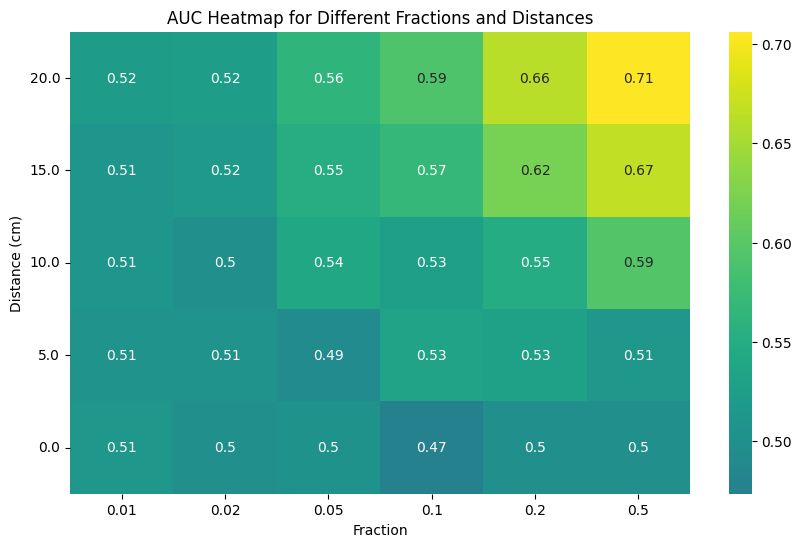

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

auc_values = pd.read_csv(r"C:\Users\Gebruiker\XENONnT_pmt_statistics\csvs\auc_results_machine_learning.csv")
distances = np.linspace(0, 20, 5)
Fractions = np.array([0.01, 0.02, 0.05, 0.1, 0.2, 0.5])

# Reverse row order so largest distance is at top
auc_values = auc_values.iloc[::-1]

plt.figure(figsize=(10, 6))
sns.heatmap(auc_values, annot=True, cmap='viridis', center=0.5)
plt.xlabel('Fraction')
plt.ylabel('Distance (cm)')
plt.title('AUC Heatmap for Different Fractions and Distances')

# Set y-axis ticks to actual distance values, reversed
plt.yticks(
    ticks=np.arange(len(distances)) + 0.5,
    labels=distances[::-1],
    rotation=0
)

plt.show()